Install libraries and load modules

In [58]:
import numpy as np
from numba import jit  # For performance optimization
from typing import Tuple
import numpy as np
import os
import matplotlib.pyplot as plt
import cartopy.crs as crs
import cartopy.feature as feature
#from cartopy.feature import NaturalEarthFeature

Observation operator

In [5]:
def model_to_obs( obs_list , model_data , model_grid ) -> Tuple[np.ndarray, np.ndarray]:
    from scipy.interpolate import interpn

    nobs = len( obs_list )                 #Number of observations
    y = np.zeros( nobs )
    obs_error = np.zeros( nobs )

    #Loop over the observations and define the observation value and observation error based on obs_list. 
    for iobs , observation in enumerate( obs_list )  : 
 
        otype = observation[0]
        oloc = np.array([observation[1],observation[2],observation[3]])
        
        if observation[0] in ['t','u','v','q','gh'] :  #Conventional observation
     
            #Create the pseudo-observation as the mean of the forecast ensemble + the innovation.
            y[iobs] = interpn( model_grid , model_data[:,:,:,var_index[observation[0]] ], oloc )
            obs_error[iobs] = observation[5] 
    
    return y , obs_error 

Localization

In [ ]:
def simple_loc(glx: int, gly: int, glz: int, 
               obs_list : list , locs: np.ndarray ) -> np.array :
    """
    Compute simple localization weights
    
    Args:
        glx, gly, glz: Grid point location
        olx, oly, olz: Observation locations (nobs)
        locs: Localization scales in x, y, z
        nobs: Number of observations
        rloc: Output localization weights (nobs)
    """
    rloc = np.ones( len(obs_list) )   #Localized observation error
    max_dist = 25.0
    for iobs , observation in enumerate( obs_list ):
        dist = 0.0
        if locs[0] > 0.0:
            dist += ((glx - observation[1])/locs[0])**2
        if locs[1] > 0.0:
            dist += ((gly - observation[2])/locs[1])**2
        if locs[2] > 0.0:
            dist += ((glz - observation[3])/locs[2])**2
        if dist <= max_dist :
            rloc[iobs] = obs_list[iobs][5] / np.exp(-0.5 * dist)
        else :
            rloc[iobs] = np.nan
    return rloc 
        

LETKF equations

In [7]:
def letkf_core( Ypert , rloc, dep, parm_infl, minfl=0.0):
    """
    LETKF Core Algorithm
    
    Parameters:
        hdxb: observation operator times forecast ensemble perturbations (nobsl x ne)
        rloc: localization weighting function (nobsl)
        dep: observation departure (yo-Hxb) (nobsl)
        parm_infl: covariance inflation parameter
        minfl: minimum covariance inflation parameter
        
    Returns:
        trans: transformation matrix (ne x ne)
        transm: transformation matrix mean (ne)
        pao: analysis covariance matrix in ensemble space (ne x ne)
        parm_infl: updated inflation parameter
    """
    nobsl , ne = np.shape(Ypert)
    
    if nobsl == 0:
        trans = np.eye(ne) * np.sqrt(parm_infl)
        transm = np.zeros(ne)
        pao = np.eye(ne) * (parm_infl / (ne - 1))
        return trans, transm, pao, parm_infl
    
    # hdxb Rinv
    Ypert_rinv = Ypert / rloc[:, np.newaxis]
    
    # hdxb^T Rinv hdxb
    work1 = Ypert_rinv.T @ Ypert
    
    # Apply minimum inflation if needed
    if minfl > 0.0 and parm_infl < minfl:
        parm_infl = minfl
    
    rho = 1.0 / parm_infl
    
    # hdxb^T Rinv hdxb + (m-1)I / rho
    work1 += np.eye(ne) * (ne - 1) * rho
    
    # Eigen decomposition
    eival, eivec = np.linalg.eig(work1)
    
    # Pa = [hdxb^T Rinv hdxb + (m-1)I]^-1
    work1 = eivec / eival
    pa = work1 @ eivec.T
    
    # Pa hdxb_rinv^T
    work2 = pa @ Ypert_rinv.T
    
    # Pa hdxb_rinv^T dep
    work3 = work2 @ dep
    
    # T = sqrt[(m-1)Pa]
    rho = np.sqrt((ne - 1) / eival)
    work1 = eivec * rho
    trans = work1 @ eivec.T
    
    # Return values
    transm = work3
    pao = pa
    
    return trans, transm, pao, parm_infl

General DA procedures


In [8]:
def simple_letkf( xf : np.ndarray , Y : np.ndarray , yo : np.ndarray ,
                     model_grid : tuple , obs_list : list , 
                     locs: np.ndarray, infl = 1.0 ) -> np.ndarray:
    """
    Simple LETKF implementation with localization
    
    Args:
        xf: Prior state (nx, ny, nz, nbv, nvar)
        Y: Prior state in observation space (nobs,nbv)
        yo: Observations (nobs)
        model_grid: tuple containing regular grid coordinates
        obs_list: list of tuples containing observation properties. 
        locs: Localization scales in x, y, z
        oerr: Observation errors (nobs)
        infl : Multiplicative inflation factor    
    Returns:
        xa: Analysis state (nx, ny, nz, nbv, nvar)
    """
    #Get the grid dimensions
    nx , ny , nz , nbv , nvar = np.shape( xf )
    
    nobs = len( obs_list )
    
    # Initialize outputs
    xa = np.zeros_like(xf)  #Arrau tp store the analysis ensemble.
    
    # Compute ensemble mean and perturbations in observation space
    Ymean = np.mean( Y , axis=1 )
    Ypert = Y - Ymean[:, np.newaxis]
    # Compute the ensemble mean observation departure
    dep = yo - Ymean    
    
    # Compute ensemble mean and perturbations in state space
    xfmean = np.mean(xf, axis=3)
    xfpert = xf - xfmean[:,:,:,np.newaxis,:]
    
    # Main assimilation loop
    #Iterate over x, y and z. 
    for ix in range(nx):
        print(f"Processing ix = {ix+1}/{nx}")
        for iy in range(ny):
            for iz in range(nz):
                
                # Compute localization weights
                rloc = simple_loc(model_grid[0][ix],model_grid[1][iy],model_grid[2][iz] 
                           , obs_list , locs)
                #Keep only the observations that are closer than dist max
                mask_loc = ~ np.isnan( rloc )
                Ypert_loc = Ypert[mask_loc,:]
                dep_loc = dep[mask_loc]
                rloc = rloc[mask_loc]
                nobs_loc = rloc.size
                
                if( nobs_loc > 0 ) :
                # Perform LETKF update
                    wa, wamean, pa , infl = letkf_core(Ypert , rloc, dep , infl , minfl=1.0)
                
                    # Apply weights to update state
                    for iv in range(nvar):
                        xa[ix, iy, iz, :, iv] = xfmean[ix,iy,iz,iv]
                        for im in range(nbv):
                            for im2 in range(nbv):
                                xa[ix, iy, iz, im, iv] += (
                                    xfpert[ix,iy,iz,im2, iv] * (wa[im2, im] + wamean[im2])
                                )
                else :
                    #No observations for this grid point. 
                    #The analysis is equal to the forecast. 
                    xa[ix,iy,iz,:,:] = xf[ix,iy,iz,:,:]
    return xa

Read the ensemble data 

In [51]:
#=========================================================
#  READ DATA
#=========================================================
from netCDF4 import Dataset  
data_file='/home/jruiz/datosdemerzel/GFSDATA/gefs.20231216/12/pgrb2b/gfs_ens.nc'
variables = ['t','u','v','q','gh']
time = 1   #Data time to be used in the experiments ( 1-6hs forecast , 2-12hs forecast , .... )

print('We are going to read the file stored in: ',data_file)
print('We will look for the following variables: ',variables)
ds = Dataset(data_file,'r')

#
nvar = 0
var_index = {}
var_list = []
file_variables = ds.variables.keys()
for my_var in variables :
    if my_var in file_variables :
        var_index[my_var] = nvar
        var_list.append( ds.variables[my_var][:] )
        nvar = nvar + 1
    else :
        print('Warning: Variable ',my_var,' is not present in the data file')
        variables.remove[my_var]

print('We found a total of ',str(nvar),' in the input file ',variables)
#Combine all variables into a single array and reorder dimensions.
xf = np.array( var_list ).transpose(5,4,3,2,0,1)[:,:,:,:,:,time] 
          
#Compute the ensemble mean.
xf_mean = np.mean( xf , axis=3)
#Compute the ensemble spread.
xf_std  = np.std( xf , axis=3)
#Get the size of the forecast ensemble (as will be used in the DA)
[nx , ny , nz , nbv , nvar] = xf.shape

#Get the data dimensions from the input file.
lon = ds.variables['longitude'][:]
lat = ds.variables['latitude'][:]
lev = ds.variables['isobaricInhPa'][:]

#Construct the model_grid tuple (will be used later for data assimilation)
model_grid = ( lon , lat , lev )


We are going to read the file stored in:  /home/jruiz/datosdemerzel/GFSDATA/gefs.20231216/12/pgrb2b/gfs_ens.nc
We will look for the following variables:  ['t', 'u', 'v', 'q', 'gh']
We found a total of  5  in the input file  ['t', 'u', 'v', 'q', 'gh']


Data summary 

In [52]:

print('We have the following dimensions')
print('Number of grid points in longitude:' , nx)
print('Number of grid points in latitude:' , ny)
print('Number of vertical levels:' , nz)
print('Number of ensemble members:' , nbv)
print('Number of model variables:' , nvar)
print('We have the following variables')
for myvar in var_index.keys() :
    print(myvar)
    
print('Minimum longitude: ',np.min(lon))
print('Maximum longitude: ',np.max(lon))
print('Minimum latitude:  ',np.min(lat))
print('Maximum latitude:  ',np.max(lat))    
print('Lower level:  ',np.max(lev))
print('Upper level:  ',np.min(lev)) 
    

We have the following dimensions
Number of grid points in longitude: 50
Number of grid points in latitude: 60
Number of vertical levels: 8
Number of ensemble members: 31
Number of model variables: 5
We have the following variables
t
u
v
q
gh
Minimum longitude:  280.25
Maximum longitude:  329.25
Minimum latitude:   -59.25
Maximum latitude:   -0.25
Lower level:   1000.0
Upper level:   300.0


Plot ensemble members, the ensemble mean and the ensemble perturbations (horizontal plot) 

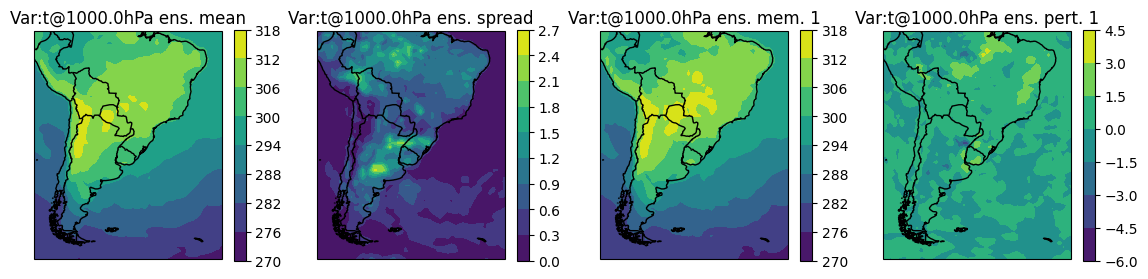

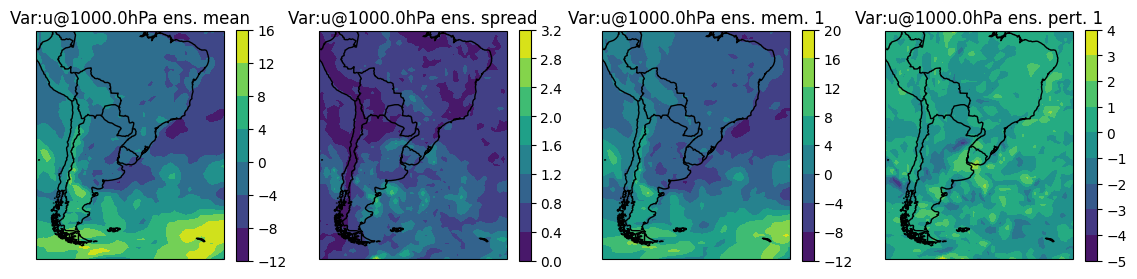

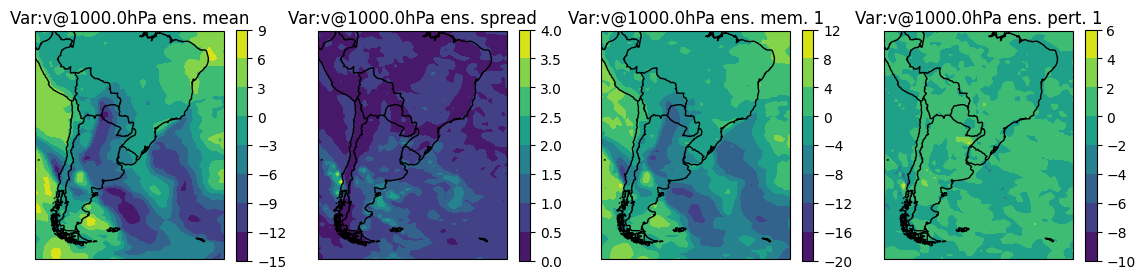

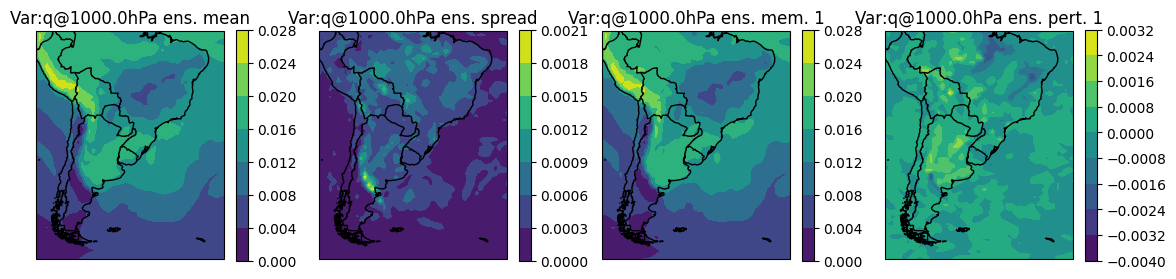

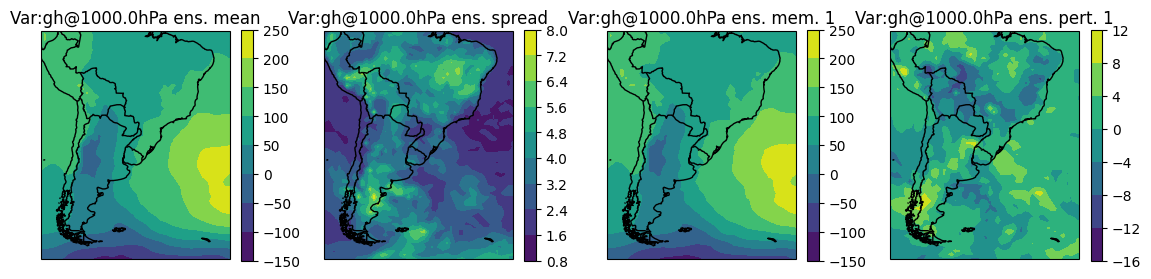

In [128]:
plot_member = 1          #Ensemble member
plot_lev    = 1000.0     #Vertical level (for horizontal plots)

idx_lev = (np.abs(lev - plot_lev)).argmin()


for my_var in var_index.keys() :
    #Horizontal plot
    fig , ax = plt.subplots(1,4,figsize=(14, 3),subplot_kw={'projection': crs.PlateCarree()})

    #Ploting ensemble mean
    cont=ax[0].contourf( lon , lat , xf_mean[:,:,idx_lev,var_index[my_var]].T )
    ax[0].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. mean')
    ax[0].add_feature(feature.COASTLINE)
    ax[0].add_feature(feature.BORDERS)
    fig.colorbar(cont, orientation='vertical')
    #Ploting the ensemble spread
    cont=ax[1].contourf( lon , lat , np.std( xf[:,:,idx_lev,:,var_index[my_var]] , axis=2  ).T )
    ax[1].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. spread')
    ax[1].add_feature(feature.COASTLINE)
    ax[1].add_feature(feature.BORDERS)
    fig.colorbar(cont, orientation='vertical')
    #Ploting member 1
    cont=ax[2].contourf( lon , lat , xf[:,:,idx_lev,plot_member,var_index[my_var]].T )
    ax[2].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. mem. ' + str(plot_member))
    ax[2].add_feature(feature.COASTLINE)
    ax[2].add_feature(feature.BORDERS)
    fig.colorbar(cont, orientation='vertical')
    #Ploting member 1 perturbation with respect to the mean
    cont=ax[3].contourf( lon , lat , xf[:,:,idx_lev,plot_member,var_index[my_var]].T - xf_mean[:,:,idx_lev,var_index[my_var]].T )
    ax[3].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. pert. ' + str(plot_member))
    ax[3].add_feature(feature.COASTLINE)
    ax[3].add_feature(feature.BORDERS)
    fig.colorbar(cont, orientation='vertical')

Plot ensemble members, the ensemble mean and the ensemble perturbations (vertical cross section)

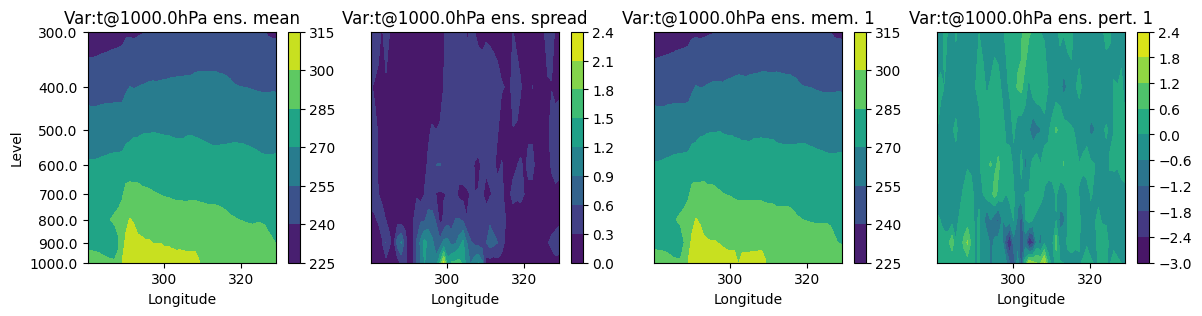

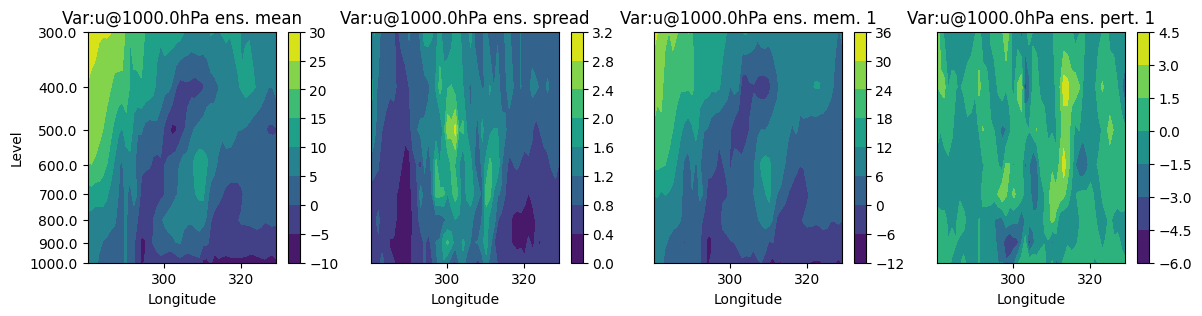

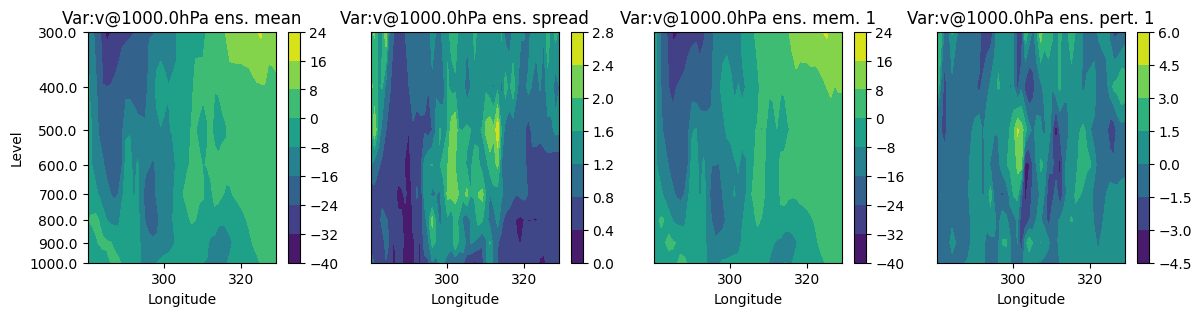

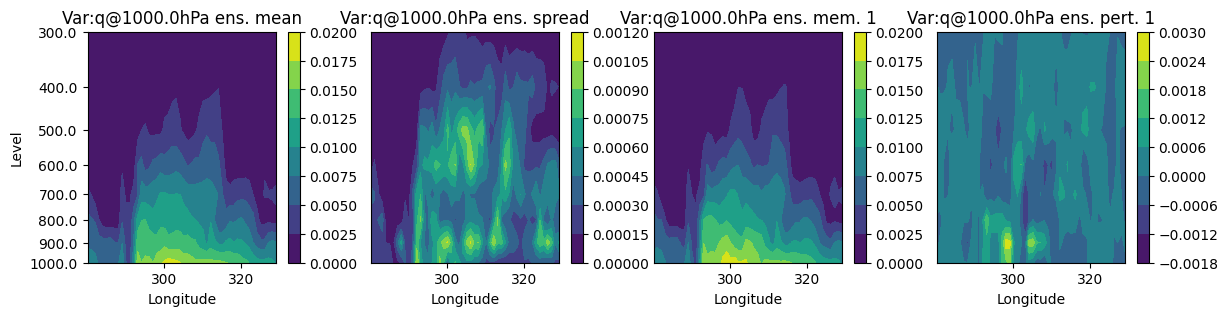

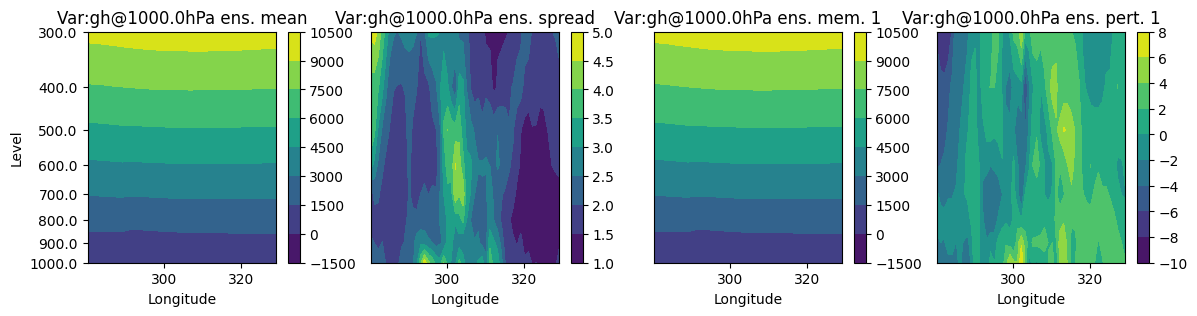

In [75]:
plot_member = 1     #Ensemble member
plot_lat    = -30   #Latitude for vertical cross section 
idx_lat = (np.abs(lat - plot_lat)).argmin()

for my_var in var_index.keys() :
    #Horizontal plot
    fig , ax = plt.subplots(1,4,figsize=(14, 3))

    #Ploting ensemble mean
    cont=ax[0].contourf( lon , -np.log(lev) , xf_mean[:,idx_lat,:,var_index[my_var]].T )
    ax[0].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. mean')
    fig.colorbar(cont, orientation='vertical')
    ax[0].set_yticks(-np.log(lev))
    ax[0].set_yticklabels(str(mylev) for mylev in lev) 
    ax[0].set_ylabel('Level')
    ax[0].set_xlabel('Longitude')
    #Ploting the ensemble spread
    cont=ax[1].contourf( lon , -np.log(lev) , np.std( xf[:,idx_lat,:,:,var_index[my_var]] , axis=2  ).T )
    ax[1].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. spread')
    fig.colorbar(cont, orientation='vertical')
    ax[1].set_yticks([])
    ax[1].set_xlabel('Longitude')
    #Ploting member 1
    cont=ax[2].contourf( lon , -np.log(lev) , xf[:,idx_lat,:,plot_member,var_index[my_var]].T )
    ax[2].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. mem. ' + str(plot_member))
    fig.colorbar(cont, orientation='vertical')
    ax[2].set_yticks([])
    ax[2].set_xlabel('Longitude')
    #Ploting member 1 perturbation with respect to the mean
    cont=ax[3].contourf( lon , -np.log(lev) , xf[:,idx_lat,:,plot_member,var_index[my_var]].T - xf_mean[:,idx_lat,:,var_index[my_var]].T )
    ax[3].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. pert. ' + str(plot_member))
    fig.colorbar(cont, orientation='vertical')
    ax[3].set_yticks([])
    ax[3].set_xlabel('Longitude')

Covariance explorer 
Horizontal structure of error localization. 

Define a function to compute the covariance between a single variable and location with the rest of the variables over the 
entire domain.

In [147]:
def ens_covariance( single_loc_xf , xf , ens_dim = 3):
    #Move ens dim to the first dimension. 
    xf = np.moveaxis(xf,ens_dim,0)
    nens , nx , ny, nz , nvar = xf.shape
    print(xf.shape)
    xf = xf.reshape(nens,-1)
    print(xf.shape)
    xf_mean = xf.mean(axis = 0)
    
    covariance =( single_loc_xf - single_loc_xf.mean() ) @ ( xf -  xf_mean ) / ( nens - 1 )
    
    # Reshape back to original non-time dimensions
    return covariance.reshape((nx,ny,nz,nvar))

In [148]:
#Select a location
point_lat = -55     #Location latitude
point_lon = 302     #Location longitude
point_lev = 500.0   #Location level
point_var = 'gh'

idx_lev = (np.abs(lev - point_lev)).argmin()
idx_lat = (np.abs(lat - point_lat)).argmin()
idx_lon = (np.abs(lon - point_lon)).argmin()

#Get the value of all ensemble members for the selected variable and selected location.
single_loc_xf = xf[idx_lon,idx_lat,idx_lev,:,var_index[point_var]]

#Compute the covariance
covariance = ens_covariance( single_loc_xf , xf , ens_dim = 3)


(31, 50, 60, 8, 5)
(31, 120000)


Plot the structure of the obtained covariance (horizontal plots)

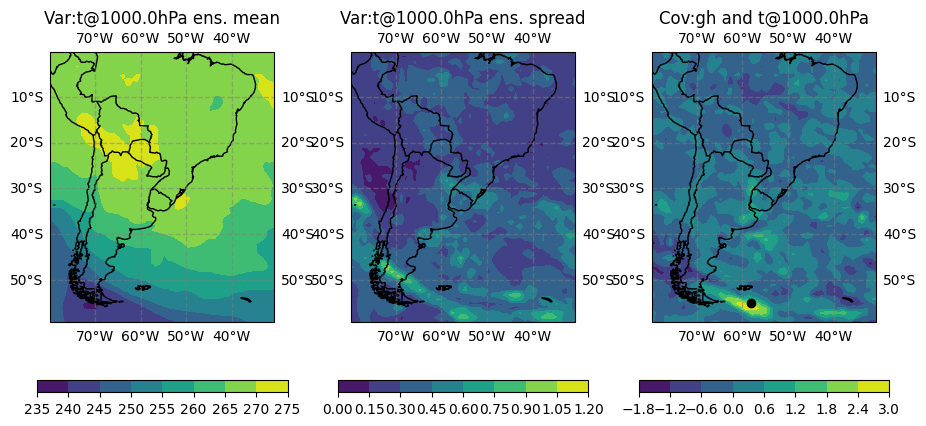

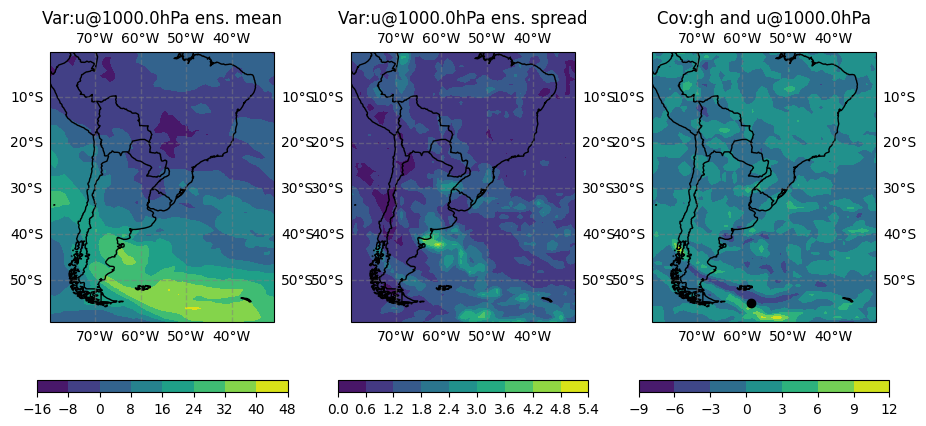

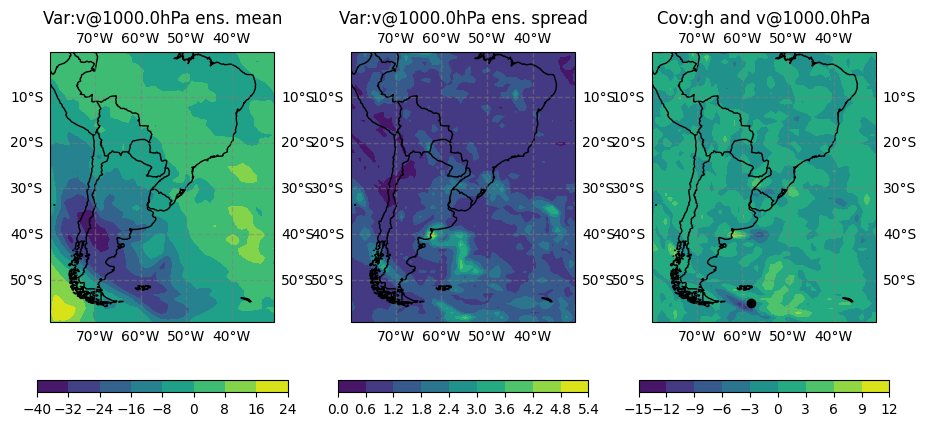

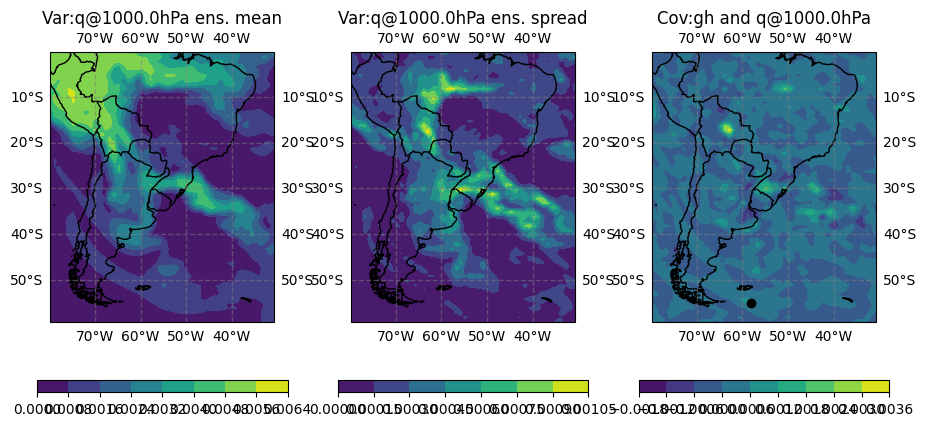

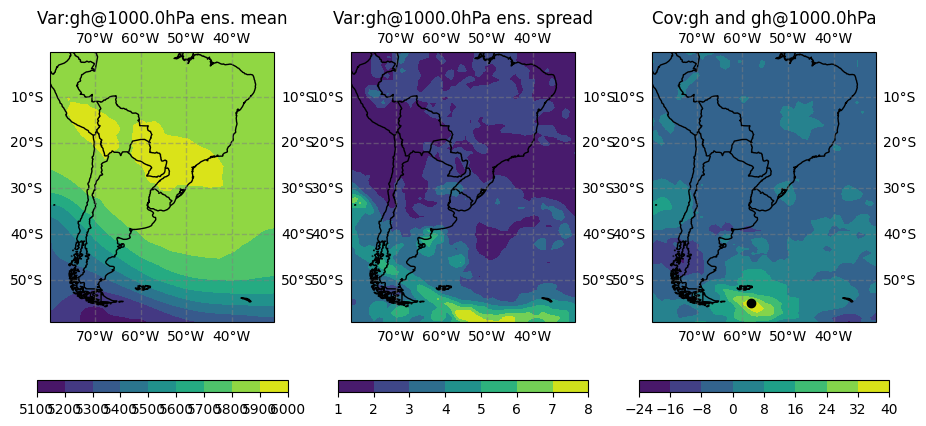

In [ ]:
for my_var in var_index.keys() :
    #Horizontal plot
    fig , ax = plt.subplots(1,3,figsize=(11, 5),subplot_kw={'projection': crs.PlateCarree()})

    #Ploting ensemble mean
    cont=ax[0].contourf( lon , lat , xf_mean[:,:,idx_lev,var_index[my_var]].T )
    ax[0].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. mean')
    ax[0].add_feature(feature.COASTLINE)
    ax[0].add_feature(feature.BORDERS)
    ax[0].gridlines(crs=crs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
    fig.colorbar(cont, orientation='horizontal')
    #Ploting the ensemble spread
    cont=ax[1].contourf( lon , lat , np.std( xf[:,:,idx_lev,:,var_index[my_var]] , axis=2  ).T )
    ax[1].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. spread')
    ax[1].add_feature(feature.COASTLINE)
    ax[1].add_feature(feature.BORDERS)
    fig.colorbar(cont, orientation='horizontal')
    ax[1].gridlines(crs=crs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')    
    #Ploting the covariance
    cont=ax[2].contourf( lon , lat , covariance[:,:,idx_lev,var_index[my_var]].T )
    ax[2].set_title('Cov:' + point_var + ' and ' + my_var + '@' + str(plot_lev) + 'hPa')
    ax[2].add_feature(feature.COASTLINE)
    ax[2].add_feature(feature.BORDERS)
    fig.colorbar(cont, orientation='horizontal')
    ax[2].gridlines(crs=crs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')    
    ax[2].plot(point_lon-360,point_lat,'ok')
   

Plot the structure of the obtained covariance (vertical cross section plots)

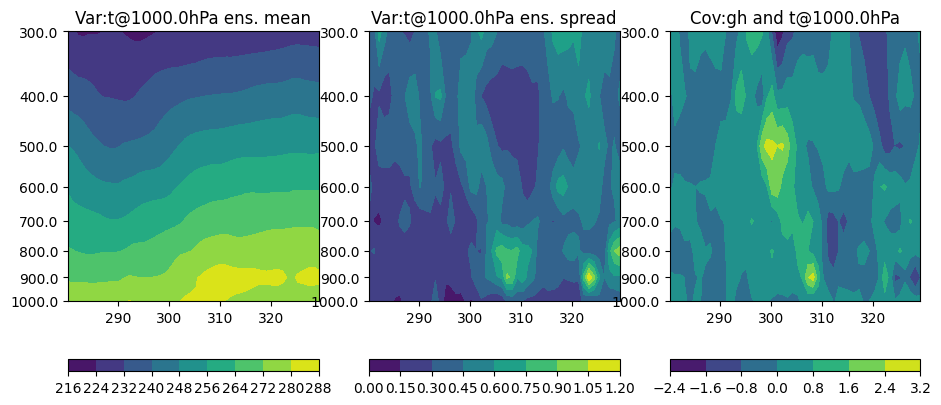

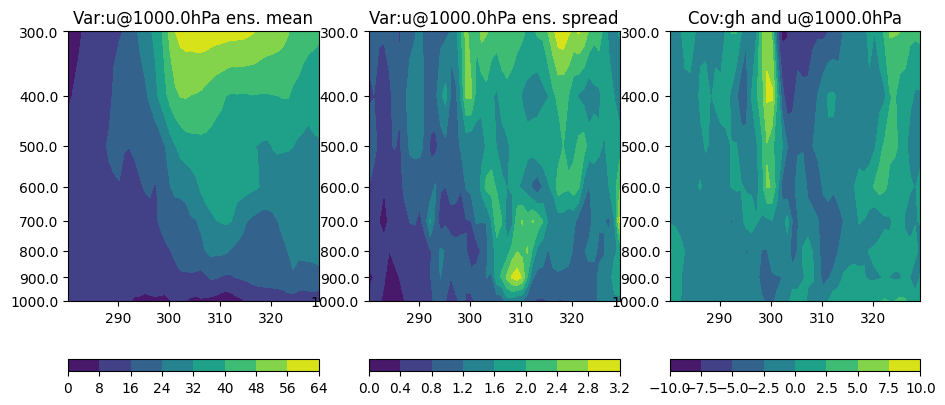

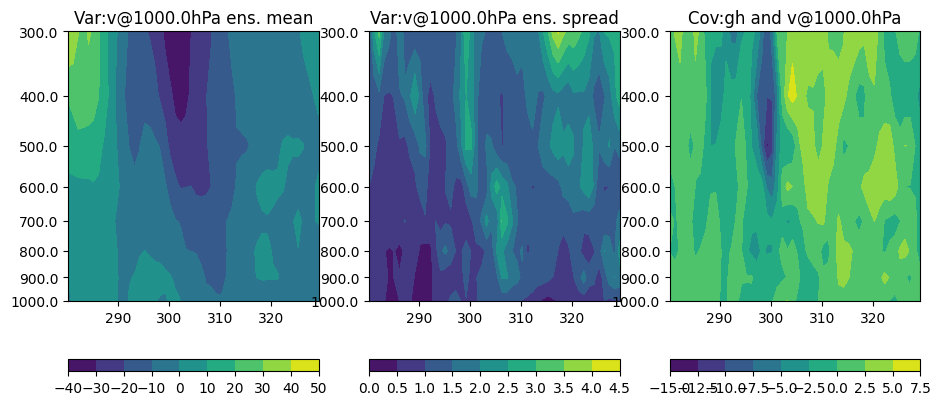

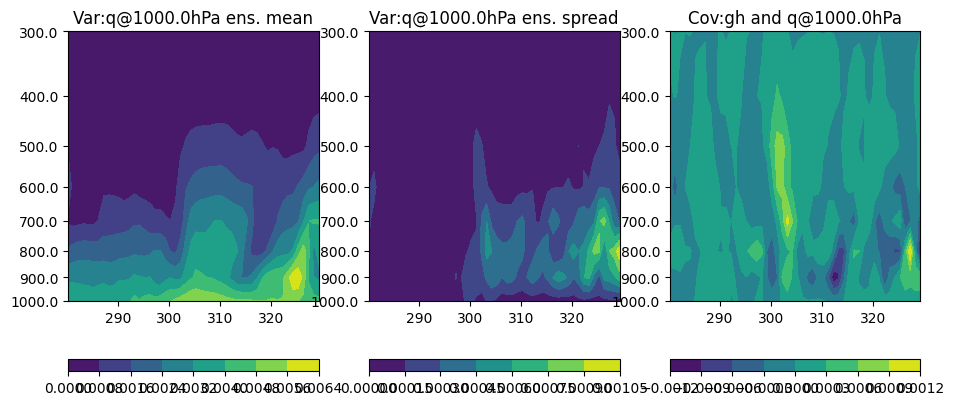

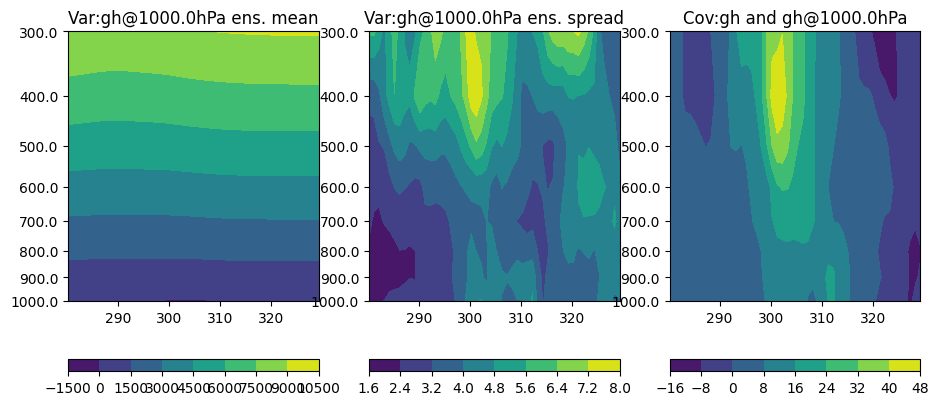

In [ ]:
for my_var in var_index.keys() :
    #Horizontal plot
    fig , ax = plt.subplots(1,3,figsize=(11, 5))

    #Ploting ensemble mean
    cont=ax[0].contourf( lon , -np.log(lev) , xf_mean[:,idx_lat,:,var_index[my_var]].T )
    ax[0].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. mean')
    ax[0].set_yticks(-np.log(lev))
    ax[0].set_yticklabels(str(mylev) for mylev in lev) 
    fig.colorbar(cont, orientation='horizontal')
    #Ploting the ensemble spread
    cont=ax[1].contourf( lon , -np.log(lev) , np.std( xf[:,idx_lat,:,:,var_index[my_var]] , axis=2  ).T )
    ax[1].set_title('Var:' + my_var + '@' + str(plot_lev) + 'hPa ' + 'ens. spread')
    ax[1].set_yticks([])
    fig.colorbar(cont, orientation='horizontal')
    #Ploting the covariance
    cont=ax[2].contourf( lon , -np.log(lev) , covariance[:,idx_lat,:,var_index[my_var]].T )
    ax[2].set_title('Cov:' + point_var + ' and ' + my_var + '@' + str(plot_lev) + 'hPa')
    ax[2].set_yticks([])
    fig.colorbar(cont, orientation='horizontal')
    #ax[2].plot(point_lon-360,point_lev,'ok')

Define the location of the observations to be assimilated and the assimilation parameters

In [ ]:
loc_scales = np.array([2.5,2.5,100])  #Localization scales in lon (degrees), lat (degrees) and z (hPas).
infl = 1.0                            #Multiplicative inflation factor

#Observations (python list)
obs_list = [ 
           [ 't' , 310 , -30.0 , 800.0 , 1.0 , 1.0 ] , #Each tuple in the list is an observation (type , lon , lat , lev , innovation ,  obs error) 
                        
           ] 


In [ ]:
"""
This is a python driver for the simple_letkf_wloc fortran routine.
This code provides a way to run simple assimilation experiments with
realistic priors. 

@author:
"""

#=========================================================
#  GET THE OBSERVATIONS
#=========================================================
print('Obtaining the observations')
#Call the observation operator to obtain the observable quantities from the ensemble mean.
yo , obs_error = model_to_obs( obs_list , xf_mean , model_grid ) 

nobs = yo.size  #Number of observations to be assimilated.
#Add observation departure to the forecast ensemble mean.     
for iobs in range( nobs ) :
    yo[iobs] = yo[iobs] + obs_list[iobs][4]

#=========================================================
#  APPLY OBSERVATION OPERATOR TO THE ENSEMBLE MEMBERS
#=========================================================
print('Applying the observation operator to the ensemble')
Y = np.zeros( ( nobs , nbv ) )  #Array that will contain the obaservable quantities as derived from each ensemble member.
for imem in range( nbv ) :  #Loop over the ensemble members.
    Y[:,imem] , _ = model_to_obs( obs_list , xf[:,:,:,imem,:] , model_grid )

#Get the ensemble mean observation departure.
dep = yo - np.mean( Y , axis = 1 ) 

#=========================================================
#  COMPUTE THE ANALYSIS UPDATE
#=========================================================
#Compute the simple analysis update
print('Computing the letkf update')
xa = simple_letkf(xf=xf,Y=Y,yo=yo,model_grid=model_grid,obs_list=obs_list,
                         locs=loc_scales , infl=infl
                         )


#Write the analysis for the update variables
print('Writing data')



Obtaining the observations


/tmp/ipykernel_1623608/1103172646.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[iobs] = interpn( model_grid , model_data[:,:,:,var_index[observation[0]] ], oloc )
/tmp/ipykernel_1623608/4017517383.py:63: ComplexWarning: Casting complex values to real discards the imaginary part
  xa[ix, iy, iz, im, iv] += (


Applying the observation operator to the ensemble
Computing the letkf update
Processing ix = 1/100
Processing ix = 2/100
Processing ix = 3/100
Processing ix = 4/100
Processing ix = 5/100
Processing ix = 6/100
Processing ix = 7/100
Processing ix = 8/100
Processing ix = 9/100
Processing ix = 10/100
Processing ix = 11/100
Processing ix = 12/100
Processing ix = 13/100
Processing ix = 14/100
Processing ix = 15/100
Processing ix = 16/100
Processing ix = 17/100
Processing ix = 18/100
Processing ix = 19/100
Processing ix = 20/100
Processing ix = 21/100
Processing ix = 22/100
Processing ix = 23/100
Processing ix = 24/100
Processing ix = 25/100
Processing ix = 26/100
Processing ix = 27/100
Processing ix = 28/100
Processing ix = 29/100
Processing ix = 30/100
Processing ix = 31/100
Processing ix = 32/100
Processing ix = 33/100
Processing ix = 34/100
Processing ix = 35/100
Processing ix = 36/100
Processing ix = 37/100
Processing ix = 38/100
Processing ix = 39/100
Processing ix = 40/100
Processing i